# 📊 Turning biased dice rolls into uniform outcomes

This notebook compares three six-sided dice: a fair die, a minimally biased die, and a highly biased die. For each, it shows both the **raw physical-roll distribution** (bias not fixed) and the distribution after applying the highest-slot extractor (bias fixed).

Run the notebook from top to bottom. The random simulation means exact values will vary a little on each run.

## Procedure: highest-slot extractor

A single biased die roll cannot generally be made fair by relabelling its faces. Instead, we use the **positions** of several independent rolls:

1. Roll the same die six times and keep the ordered sequence.
2. Find the highest face in that sequence.
3. If that highest face occurs exactly once, output its position (slot 1–6).
4. If there is a tie for the highest face, discard all six rolls and repeat.

The physical die may prefer some faces, but every slot is exchangeable: conditional on there being a unique maximum, each of the six slots is equally likely to contain it. Therefore the extracted slot is uniform. Very biased dice can require more retries because their most probable face frequently ties.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

FACES = np.arange(1, 7)
IDEAL = 1 / 6
NUM_RUNS = 10
NUM_TRIALS_PER_RUN = 10_000

# Weights are the probabilities of physical faces 1 through 6.
DICE = {
    'Fair die': [1 / 6] * 6,
    'Minimally biased die': [0.16, 0.16, 0.16, 0.16, 0.16, 0.20],
    'Highly biased die': [0.05, 0.05, 0.10, 0.10, 0.20, 0.50],
}

print(f'{NUM_RUNS} runs × {NUM_TRIALS_PER_RUN:,} trials per die')

10 runs × 10,000 trials per die


## Simulation code

Each run collects the same number of raw rolls and extracted outcomes. The extracted outcomes may consume more physical rolls due to rejected tied blocks.

In [2]:
def roll_die(weights):
    return random.choices(FACES, weights=weights, k=1)[0]


def highest_slot_extractor(weights):
    """Return (uniform slot, physical rolls used)."""
    rolls_used = 0
    while True:
        sequence = [roll_die(weights) for _ in FACES]
        rolls_used += 6
        highest = max(sequence)
        if sequence.count(highest) == 1:
            return sequence.index(highest) + 1, rolls_used


def probabilities(samples):
    return np.bincount(samples, minlength=7)[1:] / len(samples)


def run_experiment(weights, num_runs=NUM_RUNS, num_trials=NUM_TRIALS_PER_RUN):
    raw_runs, fixed_runs, mean_rolls = [], [], []
    for _ in range(num_runs):
        raw = [roll_die(weights) for _ in range(num_trials)]
        extracted = [highest_slot_extractor(weights) for _ in range(num_trials)]
        fixed, rolls = zip(*extracted)
        raw_runs.append(probabilities(raw))
        fixed_runs.append(probabilities(fixed))
        mean_rolls.append(np.mean(rolls))
    return np.array(raw_runs), np.array(fixed_runs), np.array(mean_rolls)


results = {name: run_experiment(weights) for name, weights in DICE.items()}

## Results summary

Uniformity is measured in two ways: **maximum deviation** is the largest difference from 1/6 for any face, while **total variation distance** is half the sum of all absolute differences. Both are zero for a perfectly uniform distribution; smaller is better.

Efficiency is reported as **physical rolls per extracted outcome**. Each extractor attempt consumes six rolls, so its inverse gives the fraction of six-roll blocks accepted (the **block acceptance rate**). Values below are averages across simulation runs.

In [3]:
def uniformity_metrics(probabilities):
    differences = np.abs(probabilities - IDEAL)
    return differences.max(), differences.sum() / 2


summary_rows = []
for name, weights in DICE.items():
    raw_runs, fixed_runs, mean_rolls = results[name]
    raw_mean = raw_runs.mean(axis=0)
    fixed_mean = fixed_runs.mean(axis=0)
    raw_max, raw_tv = uniformity_metrics(raw_mean)
    fixed_max, fixed_tv = uniformity_metrics(fixed_mean)
    summary_rows.append({
        'die': name,
        'raw max deviation': raw_max,
        'fixed max deviation': fixed_max,
        'raw total variation': raw_tv,
        'fixed total variation': fixed_tv,
        'physical rolls / extracted outcome': mean_rolls.mean(),
        'accepted six-roll blocks': 6 / mean_rolls.mean(),
    })

summary = summary_rows
print(f"{'Die':<24} {'Raw max':>9} {'Fixed max':>10} {'Raw TV':>8} {'Fixed TV':>9} {'Rolls/out':>10} {'Accepted':>10}")
for row in summary:
    print(f"{row['die']:<24} {row['raw max deviation']:>9.4f} {row['fixed max deviation']:>10.4f} {row['raw total variation']:>8.4f} {row['fixed total variation']:>9.4f} {row['physical rolls / extracted outcome']:>10.2f} {row['accepted six-roll blocks']:>9.1%}")

Die                        Raw max  Fixed max   Raw TV  Fixed TV  Rolls/out   Accepted
Fair die                    0.0022     0.0013   0.0026    0.0024      10.54     56.9%
Minimally biased die        0.0313     0.0011   0.0313    0.0014      11.43     52.5%
Highly biased die           0.3346     0.0009   0.3664    0.0013      61.91      9.7%


The fair die is already uniform, so fixing it does not change its distribution. The biased dice should have noticeably smaller uniformity errors after extraction, while the final columns quantify the efficiency cost. For example, a value of 60 physical rolls/outcome means that an accepted uniform result needs about ten six-roll blocks on average.

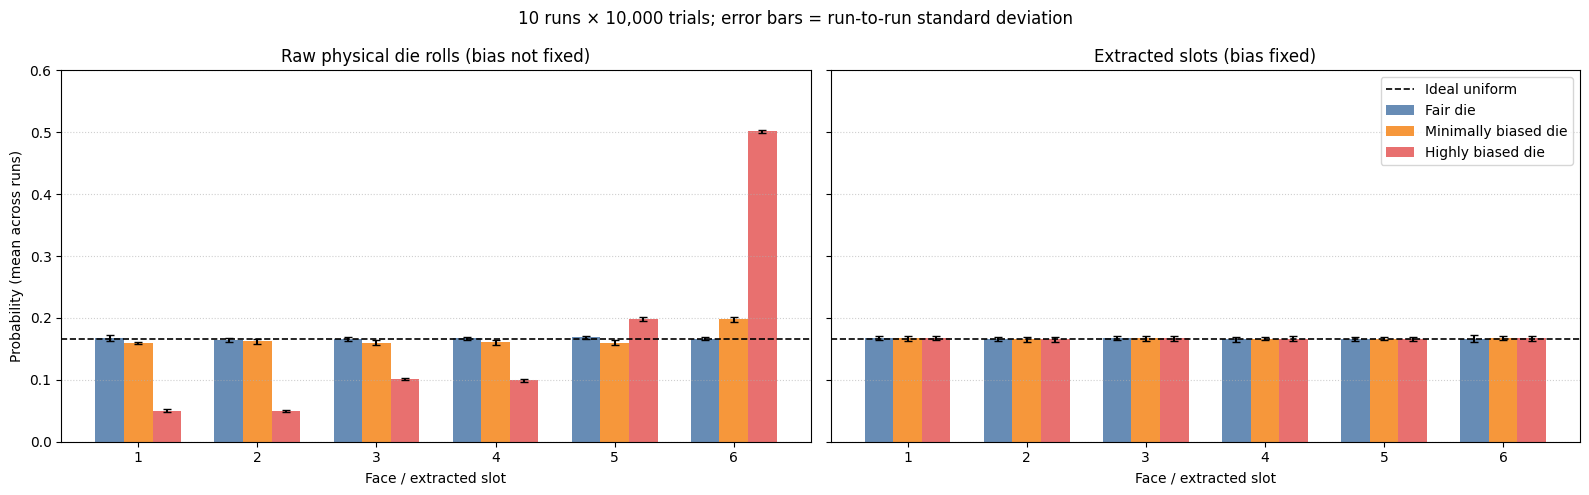

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
width = 0.24
offsets = [-width, 0, width]
colors = ['#4c78a8', '#f58518', '#e45756']

for axis, result_index, title in [
    (axes[0], 0, 'Raw physical die rolls (bias not fixed)'),
    (axes[1], 1, 'Extracted slots (bias fixed)'),
]:
    for (name, _), offset, color in zip(DICE.items(), offsets, colors):
        run_probabilities = results[name][result_index]
        axis.bar(
            FACES + offset, run_probabilities.mean(axis=0), width,
            yerr=run_probabilities.std(axis=0), capsize=3,
            label=name, color=color, alpha=0.85,
        )
    axis.axhline(IDEAL, color='black', linestyle='--', linewidth=1.2, label='Ideal uniform')
    axis.set(title=title, xlabel='Face / extracted slot', ylim=(0, 0.6))
    axis.set_xticks(FACES)
    axis.grid(axis='y', linestyle=':', alpha=0.6)

axes[0].set_ylabel('Probability (mean across runs)')
axes[1].legend()
fig.suptitle(f'{NUM_RUNS} runs × {NUM_TRIALS_PER_RUN:,} trials; error bars = run-to-run standard deviation')
plt.tight_layout()
plt.show()

## Extractor efficiency

This chart answers: **how many times must I roll the physical die to obtain one uniform outcome?** Lower bars are more efficient. The acceptance rate is shown above each bar.


Efficiency:
Fair die: 10.54 physical rolls/outcome; 56.9% of six-roll blocks accepted
Minimally biased die: 11.43 physical rolls/outcome; 52.5% of six-roll blocks accepted
Highly biased die: 61.91 physical rolls/outcome; 9.7% of six-roll blocks accepted


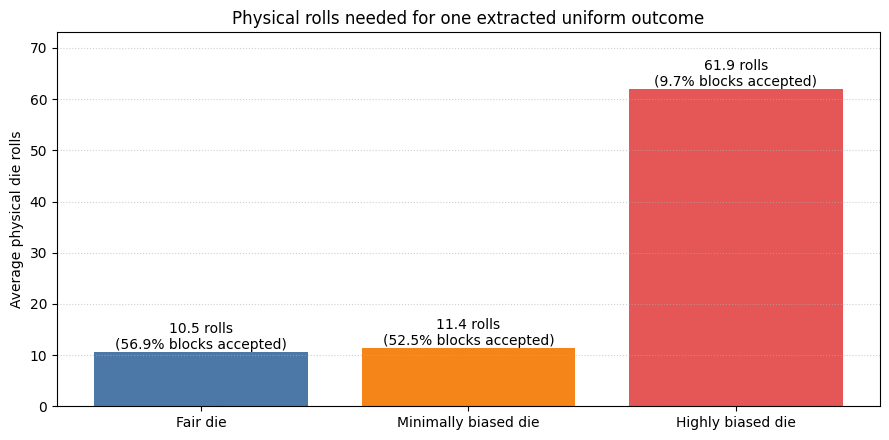

In [5]:
print('\nEfficiency:')
for row in summary:
    print(f"{row['die']}: {row['physical rolls / extracted outcome']:.2f} physical rolls/outcome; {row['accepted six-roll blocks']:.1%} of six-roll blocks accepted")

fig, ax = plt.subplots(figsize=(9, 4.5))
rolls_per_outcome = [row['physical rolls / extracted outcome'] for row in summary]
bars = ax.bar([row['die'] for row in summary], rolls_per_outcome, color=['#4c78a8', '#f58518', '#e45756'])
ax.set(title='Physical rolls needed for one extracted uniform outcome',
       ylabel='Average physical die rolls', ylim=(0, max(rolls_per_outcome) * 1.18))
ax.grid(axis='y', linestyle=':', alpha=0.6)
for bar, row in zip(bars, summary):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():.1f} rolls\n({row["accepted six-roll blocks"]:.1%} blocks accepted)',
            ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [6]:
probability_rows = []
for name in DICE:
    raw_runs, fixed_runs, _ = results[name]
    for face, raw, fixed in zip(FACES, raw_runs.mean(axis=0), fixed_runs.mean(axis=0)):
        probability_rows.append({
            'die': name, 'face / slot': face,
            'raw (unfixed)': raw, 'extractor (fixed)': fixed,
        })

for row in probability_rows:
    print(f"{row['die']:<22} face/slot {row['face / slot']}: raw={row['raw (unfixed)']:.4f}, extractor={row['extractor (fixed)']:.4f}")

Fair die               face/slot 1: raw=0.1670, extractor=0.1680
Fair die               face/slot 2: raw=0.1645, extractor=0.1660
Fair die               face/slot 3: raw=0.1663, extractor=0.1677
Fair die               face/slot 4: raw=0.1671, extractor=0.1656
Fair die               face/slot 5: raw=0.1684, extractor=0.1662
Fair die               face/slot 6: raw=0.1667, extractor=0.1665
Minimally biased die   face/slot 1: raw=0.1593, extractor=0.1669
Minimally biased die   face/slot 2: raw=0.1622, extractor=0.1656
Minimally biased die   face/slot 3: raw=0.1600, extractor=0.1671
Minimally biased die   face/slot 4: raw=0.1603, extractor=0.1666
Minimally biased die   face/slot 5: raw=0.1601, extractor=0.1665
Minimally biased die   face/slot 6: raw=0.1980, extractor=0.1674
Highly biased die      face/slot 1: raw=0.0498, extractor=0.1671
Highly biased die      face/slot 2: raw=0.0498, extractor=0.1657
Highly biased die      face/slot 3: raw=0.1014, extractor=0.1673
Highly biased die      fa

## Conclusion

The raw chart and table reveal each die's physical bias. The extractor chart should be close to the dashed 1/6 line for every die, including the highly biased die. The trade-off is efficiency: stronger bias produces more tied maxima, so more physical rolls are needed for each accepted uniform outcome. Use the efficiency chart to estimate the number of launches/rolls you need for your chosen die.

In [ ]:
# Shannon entropy is calculated separately for every simulation run.
def shannon_entropy(probabilities):
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

entropy_summary = []
for name, (raw_runs, extracted_runs, _) in results.items():
    raw_entropy = np.array([shannon_entropy(probabilities) for probabilities in raw_runs])
    extracted_entropy = np.array([shannon_entropy(probabilities) for probabilities in extracted_runs])
    entropy_summary.append((name, raw_entropy.mean(), extracted_entropy.mean(), raw_entropy.std(), extracted_entropy.std()))

print(f"{'Die':<24} {'Raw entropy':>12} {'Extracted entropy':>18}")
for name, raw_entropy, extracted_entropy, _, _ in entropy_summary:
    print(f"{name:<24} {raw_entropy:>11.4f} bits {extracted_entropy:>15.4f} bits")

positions = np.arange(len(entropy_summary)); width = 0.36
fig, axis = plt.subplots(figsize=(9, 4.5))
raw_bars = axis.bar(positions - width / 2, [row[1] for row in entropy_summary], width, yerr=[row[3] for row in entropy_summary], capsize=3, label='Raw rolls', color='#f58518')
extracted_bars = axis.bar(positions + width / 2, [row[2] for row in entropy_summary], width, yerr=[row[4] for row in entropy_summary], capsize=3, label='After extractor', color='#4c78a8')
maximum_entropy = np.log2(len(FACES))
axis.axhline(maximum_entropy, color='black', linestyle='--', label='Maximum entropy')
axis.set(title='Shannon entropy: raw rolls vs extracted outcomes', xlabel='Die bias', ylabel='Bits per outcome', xticks=positions, xticklabels=[row[0] for row in entropy_summary], ylim=(0, maximum_entropy * 1.12))
axis.grid(axis='y', linestyle=':', alpha=0.6); axis.legend()
for bars in (raw_bars, extracted_bars):
    for bar in bars:
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()